# ACSIncome Business Rule Gap


In [7]:
# 0. Cài thư viện trên Google Colab
!pip -q install folktables tqdm

In [8]:
# 1. Imports và cấu hình
import math
import random
import warnings
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm
from scipy.stats import entropy
from sklearn.metrics import (
    mutual_info_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# Cấu hình chính
SURVEY_YEAR = "2018"
STATES = ["CA", "TX", "NY", "FL", "IL"]
ANALYSIS_SAMPLE_SIZE = 100_000
TEST_SIZE = 0.20

RANDOM_SEED = 42
STRESS_SEEDS = [42, 52, 62, 72, 82]
DDS_SEEDS = [42, 52, 62]

NOISE_RATES = [0.01, 0.05, 0.10]
TOP_KS = [6, 12, 18, 30]

# Mined-rule configuration
MINED_RULE_LIMIT = 12
MIN_THEILS_U = 0.95
MIN_GROUP_SUPPORT = 5
MIN_GROUP_PURITY = 0.98
MAX_RHS_CARDINALITY = 30

# DDS configuration (giảm kích thước để Colab chạy ổn)
DDS_SAMPLE_SIZE = 5_000
DDS_BOOTSTRAP_REPS = 10

print("Cấu hình đã sẵn sàng.")

Cấu hình đã sẵn sàng.


## 2. Tải dữ liệu ACSIncome và lấy mẫu

Notebook tải dữ liệu ACSIncome năm 2018 từ 5 bang. Sau đó lấy mẫu phân tầng theo `state × income_label` để giữ tương đối cấu trúc dữ liệu ban đầu.

In [9]:
# 2. Tải ACSIncome theo bang
from folktables import ACSDataSource, ACSIncome

def load_acs_income_by_state(states: List[str], survey_year: str = "2018") -> pd.DataFrame:
    data_source = ACSDataSource(
        survey_year=survey_year,
        horizon="1-Year",
        survey="person"
    )

    parts = []
    for state in tqdm(states, desc="Tải ACSIncome theo bang"):
        acs_data = data_source.get_data(states=[state], download=True)
        features, labels, _ = ACSIncome.df_to_pandas(acs_data)

        part = features.copy()
        part["income_label"] = labels.astype(int).to_numpy()
        part["state"] = state
        parts.append(part)

    result = pd.concat(parts, ignore_index=True)
    return result

raw_df = load_acs_income_by_state(STATES, SURVEY_YEAR)

print("Dữ liệu thô:", raw_df.shape)
display(raw_df.head())

Tải ACSIncome theo bang:   0%|          | 0/5 [00:00<?, ?it/s]

Dữ liệu thô: (600551, 12)


,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,income_label,state
0,30.0,6.0,14.0,1.0,9610.0,6.0,16.0,40.0,1.0,8.0,0,CA
1,21.0,4.0,16.0,5.0,1970.0,6.0,17.0,20.0,1.0,1.0,0,CA
2,65.0,2.0,22.0,5.0,2040.0,6.0,17.0,8.0,1.0,1.0,0,CA
3,33.0,1.0,14.0,3.0,9610.0,36.0,16.0,40.0,1.0,1.0,0,CA
4,18.0,2.0,19.0,5.0,1021.0,6.0,17.0,18.0,2.0,1.0,0,CA


In [10]:
# 3. Lấy mẫu phân tầng state × income_label
def stratified_sample(
    df: pd.DataFrame,
    n: int | None,
    strata_cols: List[str],
    seed: int = 42
) -> pd.DataFrame:
    if n is None or n >= len(df):
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)

    frac = n / len(df)

    sampled = (
        df.groupby(strata_cols, group_keys=False, observed=True)
          .apply(lambda g: g.sample(
              n=max(1, min(len(g), int(round(len(g) * frac)))),
              random_state=seed
          ))
          .reset_index(drop=True)
    )

    # Điều chỉnh để gần đúng chính xác n dòng
    if len(sampled) > n:
        sampled = sampled.sample(n=n, random_state=seed)
    elif len(sampled) < n:
        remaining = df.drop(index=sampled.index, errors="ignore")
        add_n = min(n - len(sampled), len(remaining))
        if add_n > 0:
            sampled = pd.concat([
                sampled,
                remaining.sample(n=add_n, random_state=seed)
            ], ignore_index=True)

    return sampled.sample(frac=1, random_state=seed).reset_index(drop=True)

sampled_df = stratified_sample(
    raw_df,
    ANALYSIS_SAMPLE_SIZE,
    ["state", "income_label"],
    RANDOM_SEED
)

print("Tập phân tích:", sampled_df.shape)
print("\nPhân bố theo bang:")
display(sampled_df["state"].value_counts().rename("count").to_frame())

print("\nPhân bố nhãn thu nhập:")
display(
    sampled_df["income_label"]
      .value_counts(normalize=True)
      .mul(100)
      .round(3)
      .rename("percent")
      .to_frame()
)

Tập phân tích: (100000, 12)

Phân bố theo bang:


,count
state,
CA,32579
TX,22634
NY,17155
FL,16473
IL,11159



Phân bố nhãn thu nhập:


,percent
income_label,
0,61.402
1,38.598


## 3. Tạo biến dẫn xuất và rule catalog mô phỏng

Các biến dẫn xuất và rule catalog do **người nghiên cứu thiết kế**, không phải do máy tự tạo và không phải rule chính thức của ACSIncome.

Máy chỉ được dùng để khai phá dependency trên tập train; rule catalog chỉ được dùng **sau đó** để đánh giá mức độ khớp.

In [11]:
# 4. Tạo biến dẫn xuất
def create_derived_variables(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    # Chuyển các cột cần thiết sang dạng số
    numeric_cols = [
        "AGEP", "SCHL", "MAR", "WKHP",
        "SEX", "RELP", "COW", "income_label"
    ]

    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    # Hàm hỗ trợ tạo biến dạng chuỗi.
    # Dùng default=None thay cho np.nan để tránh lỗi NumPy mới
    # khi trộn dữ liệu chuỗi và số thực.
    def text_select(conditions, choices):
        return pd.Series(
            np.select(
                conditions,
                choices,
                default=None
            ),
            index=out.index,
            dtype="string"
        )

    # Nhóm tuổi
    out["age_group"] = text_select(
        [
            out["AGEP"] < 18,
            out["AGEP"].between(18, 64, inclusive="both"),
            out["AGEP"] >= 65,
        ],
        [
            "Under18",
            "WorkingAge",
            "Senior"
        ]
    )

    # Nhóm trình độ học vấn
    out["education_group"] = text_select(
        [
            out["SCHL"] <= 15,
            out["SCHL"].between(16, 20, inclusive="both"),
            out["SCHL"] >= 21,
        ],
        [
            "BelowHS",
            "HS_College",
            "BachelorPlus"
        ]
    )

    # Nhóm thời gian làm việc
    out["working_hours_group"] = text_select(
        [
            out["WKHP"].between(1, 14, inclusive="both"),
            out["WKHP"].between(15, 34, inclusive="both"),
            out["WKHP"].between(35, 45, inclusive="both"),
            out["WKHP"] > 45,
        ],
        [
            "VeryLow",
            "PartTime",
            "Standard",
            "Overtime"
        ]
    )

    # Trạng thái làm toàn thời gian
    # Không dùng np.where lồng np.nan vì cũng gây lỗi dtype
    out["fulltime_status"] = pd.Series(
        pd.NA,
        index=out.index,
        dtype="string"
    )

    valid_working_hours = out["WKHP"].notna()

    out.loc[valid_working_hours, "fulltime_status"] = np.where(
        out.loc[valid_working_hours, "WKHP"] >= 35,
        "Fulltime",
        "NonFulltime"
    )

    # Nhóm tình trạng hôn nhân
    out["marital_group"] = text_select(
        [
            out["MAR"] == 1,
            out["MAR"].isin([2, 3, 4, 5])
        ],
        [
            "Married",
            "NotMarried"
        ]
    )

    # Nhóm thu nhập
    out["income_group"] = text_select(
        [
            out["income_label"] == 1,
            out["income_label"] == 0
        ],
        [
            "HighIncome",
            "LowIncome"
        ]
    )

    return out


df = create_derived_variables(sampled_df)

print("Dữ liệu sau khi tạo biến dẫn xuất:", df.shape)

display(
    df[
        [
            "AGEP",
            "age_group",
            "SCHL",
            "education_group",
            "WKHP",
            "working_hours_group",
            "fulltime_status",
            "MAR",
            "marital_group",
            "income_label",
            "income_group"
        ]
    ].head()
)

Dữ liệu sau khi tạo biến dẫn xuất: (100000, 18)


,AGEP,age_group,SCHL,education_group,WKHP,working_hours_group,fulltime_status,MAR,marital_group,income_label,income_group
0,49.0,WorkingAge,21.0,BachelorPlus,45.0,Standard,Fulltime,3.0,NotMarried,1,HighIncome
1,28.0,WorkingAge,24.0,BachelorPlus,42.0,Standard,Fulltime,1.0,Married,1,HighIncome
2,66.0,Senior,23.0,BachelorPlus,20.0,PartTime,NonFulltime,3.0,NotMarried,1,HighIncome
3,31.0,WorkingAge,21.0,BachelorPlus,40.0,Standard,Fulltime,5.0,NotMarried,0,LowIncome
4,54.0,WorkingAge,20.0,HS_College,40.0,Standard,Fulltime,3.0,NotMarried,0,LowIncome


In [12]:
# 5. Rule catalog mô phỏng
business_rule_catalog = pd.DataFrame([
    {"family_id": "F1", "lhs": "AGEP", "rhs": "age_group",
     "meaning": "Tuổi phải khớp nhóm tuổi"},
    {"family_id": "F2", "lhs": "SCHL", "rhs": "education_group",
     "meaning": "Mã học vấn phải khớp nhóm học vấn"},
    {"family_id": "F3", "lhs": "WKHP", "rhs": "working_hours_group",
     "meaning": "Giờ làm phải khớp nhóm giờ làm"},
    {"family_id": "F4", "lhs": "WKHP", "rhs": "fulltime_status",
     "meaning": "Giờ làm phải khớp trạng thái toàn thời gian"},
    {"family_id": "F5", "lhs": "MAR", "rhs": "marital_group",
     "meaning": "Mã hôn nhân phải khớp nhóm hôn nhân"},
    {"family_id": "F6", "lhs": "income_label", "rhs": "income_group",
     "meaning": "Nhãn thu nhập phải khớp nhóm thu nhập"},
])

validity_rule_catalog = pd.DataFrame([
    {"rule_id": "V1", "column": "AGEP", "expression": "17 <= AGEP <= 99"},
    {"rule_id": "V2", "column": "SCHL", "expression": "1 <= SCHL <= 24"},
    {"rule_id": "V3", "column": "MAR", "expression": "MAR ∈ {1,2,3,4,5}"},
    {"rule_id": "V4", "column": "WKHP", "expression": "1 <= WKHP <= 99"},
    {"rule_id": "V5", "column": "SEX", "expression": "SEX ∈ {1,2}"},
    {"rule_id": "V6", "column": "income_label", "expression": "income_label ∈ {0,1}"},
])

print("6 rule dạng quan hệ giữa hai cột:")
display(business_rule_catalog)

print("\n6 rule miền giá trị/codebook:")
display(validity_rule_catalog)

6 rule dạng quan hệ giữa hai cột:


,family_id,lhs,rhs,meaning
0,F1,AGEP,age_group,Tuổi phải khớp nhóm tuổi
1,F2,SCHL,education_group,Mã học vấn phải khớp nhóm học vấn
2,F3,WKHP,working_hours_group,Giờ làm phải khớp nhóm giờ làm
3,F4,WKHP,fulltime_status,Giờ làm phải khớp trạng thái toàn thời gian
4,F5,MAR,marital_group,Mã hôn nhân phải khớp nhóm hôn nhân
5,F6,income_label,income_group,Nhãn thu nhập phải khớp nhóm thu nhập



6 rule miền giá trị/codebook:


,rule_id,column,expression
0,V1,AGEP,17 <= AGEP <= 99
1,V2,SCHL,1 <= SCHL <= 24
2,V3,MAR,"MAR ∈ {1,2,3,4,5}"
3,V4,WKHP,1 <= WKHP <= 99
4,V5,SEX,"SEX ∈ {1,2}"
5,V6,income_label,"income_label ∈ {0,1}"


## 4. Chia train/test

- **Train:** máy dùng để khai phá dependency và học mapping.
- **Test:** dùng để kiểm tra khả năng khái quát và thực hiện stress test.
- Việc chia mẫu vẫn giữ tương đối tỷ lệ `state × income_label`.

In [13]:
# 6. Chia train/test theo state × income_label
def stratified_train_test_split(
    data: pd.DataFrame,
    test_size: float = 0.20,
    seed: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    strata = data["state"].astype(str) + "__" + data["income_label"].astype(str)

    train_idx, test_idx = train_test_split(
        np.arange(len(data)),
        test_size=test_size,
        random_state=seed,
        stratify=strata
    )

    train = data.iloc[train_idx].reset_index(drop=True)
    test = data.iloc[test_idx].reset_index(drop=True)
    return train, test

train_df, test_df = stratified_train_test_split(df, TEST_SIZE, RANDOM_SEED)

profile = pd.DataFrame([
    {"Tập": "Toàn bộ", "Số dòng": len(df), "Số cột": df.shape[1]},
    {"Tập": "Train", "Số dòng": len(train_df), "Số cột": train_df.shape[1]},
    {"Tập": "Test", "Số dòng": len(test_df), "Số cột": test_df.shape[1]},
])

display(profile)

,Tập,Số dòng,Số cột
0,Toàn bộ,100000,18
1,Train,80000,18
2,Test,20000,18


## 5. Rule checker của chuyên gia

`ExpertRules` sử dụng:

- 16 phép kiểm tra chi tiết từ 6 rule giữa hai cột.
- 6 rule miền giá trị.
- Kiểm tra missing ở các cột quan trọng.

In [14]:
# 7. Rule checker
def check_dependency_like_rules(data: pd.DataFrame) -> pd.DataFrame:
    out = data
    v = pd.DataFrame(False, index=out.index, columns=[])

    v["R1_age_under18"] = (out["AGEP"] < 18) & (out["age_group"] != "Under18")
    v["R1_age_working"] = out["AGEP"].between(18, 64, inclusive="both") & (out["age_group"] != "WorkingAge")
    v["R1_age_senior"] = (out["AGEP"] >= 65) & (out["age_group"] != "Senior")

    v["R2_edu_belowhs"] = (out["SCHL"] <= 15) & (out["education_group"] != "BelowHS")
    v["R2_edu_hscollege"] = out["SCHL"].between(16, 20, inclusive="both") & (out["education_group"] != "HS_College")
    v["R2_edu_bachelorplus"] = (out["SCHL"] >= 21) & (out["education_group"] != "BachelorPlus")

    v["R3_hours_verylow"] = out["WKHP"].between(1, 14, inclusive="both") & (out["working_hours_group"] != "VeryLow")
    v["R3_hours_parttime"] = out["WKHP"].between(15, 34, inclusive="both") & (out["working_hours_group"] != "PartTime")
    v["R3_hours_standard"] = out["WKHP"].between(35, 45, inclusive="both") & (out["working_hours_group"] != "Standard")
    v["R3_hours_overtime"] = (out["WKHP"] > 45) & (out["working_hours_group"] != "Overtime")

    v["R4_fulltime_yes"] = (out["WKHP"] >= 35) & (out["fulltime_status"] != "Fulltime")
    v["R4_fulltime_no"] = (out["WKHP"] < 35) & (out["fulltime_status"] != "NonFulltime")

    v["R5_married"] = (out["MAR"] == 1) & (out["marital_group"] != "Married")
    v["R5_not_married"] = out["MAR"].isin([2, 3, 4, 5]) & (out["marital_group"] != "NotMarried")

    v["R6_income_high"] = (out["income_label"] == 1) & (out["income_group"] != "HighIncome")
    v["R6_income_low"] = (out["income_label"] == 0) & (out["income_group"] != "LowIncome")

    return v.fillna(False)

def check_validity_rules(data: pd.DataFrame) -> pd.DataFrame:
    v = pd.DataFrame(index=data.index)

    v["V1_AGEP"] = data["AGEP"].isna() | ~data["AGEP"].between(17, 99, inclusive="both")
    v["V2_SCHL"] = data["SCHL"].isna() | ~data["SCHL"].between(1, 24, inclusive="both")
    v["V3_MAR"] = data["MAR"].isna() | ~data["MAR"].isin([1, 2, 3, 4, 5])
    v["V4_WKHP"] = data["WKHP"].isna() | ~data["WKHP"].between(1, 99, inclusive="both")
    v["V5_SEX"] = data["SEX"].isna() | ~data["SEX"].isin([1, 2])
    v["V6_income"] = data["income_label"].isna() | ~data["income_label"].isin([0, 1])

    # Missing ở biến dẫn xuất cũng là lỗi
    for col in [
        "age_group", "education_group", "working_hours_group",
        "fulltime_status", "marital_group", "income_group"
    ]:
        v[f"MISSING_{col}"] = data[col].isna()

    return v.fillna(False)

def expert_rule_validator(data: pd.DataFrame) -> np.ndarray:
    dep_error = check_dependency_like_rules(data).any(axis=1)
    validity_error = check_validity_rules(data).any(axis=1)
    return (dep_error | validity_error).to_numpy()

clean_check = check_dependency_like_rules(test_df)
clean_summary = pd.DataFrame({
    "rule": clean_check.columns,
    "violations": clean_check.sum().to_numpy()
})
clean_summary["violation_rate"] = clean_summary["violations"] / len(test_df)

print("Kiểm tra dữ liệu test sạch:")
display(clean_summary)

Kiểm tra dữ liệu test sạch:


,rule,violations,violation_rate
0,R1_age_under18,0,0.0
1,R1_age_working,0,0.0
2,R1_age_senior,0,0.0
3,R2_edu_belowhs,0,0.0
4,R2_edu_hscollege,0,0.0
5,R2_edu_bachelorplus,0,0.0
6,R3_hours_verylow,0,0.0
7,R3_hours_parttime,0,0.0
8,R3_hours_standard,0,0.0
9,R3_hours_overtime,0,0.0


## 6. Dependency metrics và khai phá rule trên train

Máy không được cung cấp danh sách 6 rule mô phỏng. Máy chỉ nhìn dữ liệu train và tính điểm quan hệ cho mọi cặp cột.

V3.1 sử dụng:

- ExactFD.
- QStrength.
- Theil's U.
- Mutual Information.
- Cramér's V.

In [15]:
# 8. Các metric dependency
def as_cat_series(series: pd.Series) -> pd.Series:
    return series.astype("object").where(~series.isna(), "__MISSING__").astype(str)

def exact_fd_score(data: pd.DataFrame, lhs: str, rhs: str) -> float:
    x = as_cat_series(data[lhs])
    y = as_cat_series(data[rhs])
    tmp = pd.DataFrame({"x": x, "y": y})
    max_unique = tmp.groupby("x", observed=True)["y"].nunique(dropna=False).max()
    return float(max_unique == 1)

def q_strength(data: pd.DataFrame, lhs: str, rhs: str) -> float:
    x = as_cat_series(data[lhs])
    y = as_cat_series(data[rhs])

    rhs_domain = max(y.nunique(dropna=False), 1)
    grouped = pd.DataFrame({"x": x, "y": y}).groupby("x", observed=True)

    weighted_ratio = 0.0
    total = len(data)

    for _, group in grouped:
        ratio = group["y"].nunique(dropna=False) / rhs_domain
        weighted_ratio += len(group) / total * ratio

    return float(1.0 - weighted_ratio)

def theils_u(data: pd.DataFrame, lhs: str, rhs: str) -> float:
    x = as_cat_series(data[lhs])
    y = as_cat_series(data[rhs])

    h_y = entropy(y.value_counts(normalize=True), base=2)
    if h_y == 0:
        return 1.0

    mi = mutual_info_score(x, y)
    return float(max(0.0, min(1.0, mi / h_y)))

def normalized_mutual_information(data: pd.DataFrame, col1: str, col2: str) -> float:
    x = as_cat_series(data[col1])
    y = as_cat_series(data[col2])

    mi = mutual_info_score(x, y)
    h_x = entropy(x.value_counts(normalize=True), base=2)
    h_y = entropy(y.value_counts(normalize=True), base=2)

    denom = max(h_x, h_y)
    return float(mi / denom) if denom > 0 else 1.0

def cramers_v(data: pd.DataFrame, col1: str, col2: str) -> float:
    x = as_cat_series(data[col1])
    y = as_cat_series(data[col2])

    table = pd.crosstab(x, y)
    if table.empty:
        return 0.0

    observed = table.to_numpy()
    n = observed.sum()
    if n == 0:
        return 0.0

    row_sum = observed.sum(axis=1, keepdims=True)
    col_sum = observed.sum(axis=0, keepdims=True)
    expected = row_sum @ col_sum / n

    valid = expected > 0
    chi2 = (((observed - expected) ** 2) / np.where(valid, expected, 1))[valid].sum()

    r, k = observed.shape
    denom = min(k - 1, r - 1)
    if denom <= 0:
        return 0.0

    return float(np.sqrt((chi2 / n) / denom))

In [16]:
# 9. Tính điểm dependency trên train
CORE_COLS = [
    "AGEP", "SCHL", "MAR", "WKHP", "SEX", "RELP", "COW",
    "income_label", "state",
    "age_group", "education_group", "working_hours_group",
    "fulltime_status", "marital_group", "income_group"
]
CORE_COLS = [c for c in CORE_COLS if c in train_df.columns]

directed_rows = []
for lhs in tqdm(CORE_COLS, desc="Directed dependency"):
    for rhs in CORE_COLS:
        if lhs == rhs:
            continue

        directed_rows.append({
            "lhs": lhs,
            "rhs": rhs,
            "ExactFD": exact_fd_score(train_df, lhs, rhs),
            "QStrength": q_strength(train_df, lhs, rhs),
            "TheilsU_train": theils_u(train_df, lhs, rhs),
            "TheilsU_test": theils_u(test_df, lhs, rhs),
            "rhs_cardinality": train_df[rhs].nunique(dropna=False),
        })

directed_scores = pd.DataFrame(directed_rows)
directed_scores["generalization_gap"] = (
    directed_scores["TheilsU_train"] - directed_scores["TheilsU_test"]
)

undirected_rows = []
for i, col1 in enumerate(CORE_COLS):
    for col2 in CORE_COLS[i + 1:]:
        undirected_rows.append({
            "col1": col1,
            "col2": col2,
            "MutualInfo": normalized_mutual_information(train_df, col1, col2),
            "CramersV": cramers_v(train_df, col1, col2),
        })

undirected_scores = pd.DataFrame(undirected_rows)

print("Top dependency có hướng theo Theil's U trên train:")
display(
    directed_scores
      .sort_values(["TheilsU_train", "QStrength", "ExactFD"], ascending=False)
      .head(20)
)

Directed dependency:   0%|          | 0/15 [00:00<?, ?it/s]

Top dependency có hướng theo Theil's U trên train:


,lhs,rhs,ExactFD,QStrength,TheilsU_train,TheilsU_test,rhs_cardinality,generalization_gap
52,WKHP,working_hours_group,1.0,7.500000e-01,0.693147,0.693147,4,8.881784e-16
23,SCHL,education_group,1.0,6.666667e-01,0.693147,0.693147,3,1.221245e-15
111,income_label,income_group,1.0,5.000000e-01,0.693147,0.693147,2,6.661338e-16
203,income_group,income_label,1.0,5.000000e-01,0.693147,0.693147,2,6.661338e-16
53,WKHP,fulltime_status,1.0,5.000000e-01,0.693147,0.693147,2,4.440892e-16
40,MAR,marital_group,1.0,5.000000e-01,0.693147,0.693147,2,1.110223e-16
8,AGEP,age_group,1.0,6.666667e-01,0.693147,0.693147,3,8.881784e-16
165,working_hours_group,fulltime_status,1.0,5.000000e-01,0.693147,0.693147,2,-5.551115e-16
184,marital_group,MAR,0.0,5.193800e-01,0.438315,0.443490,5,-5.175593e-03
179,fulltime_status,working_hours_group,0.0,5.000000e-01,0.348604,0.347130,4,1.473972e-03


## 7. Alignment: BRR@K, Precision@K, Recall@K và NPDR@K

- **Recall@K = BRR@K:** tỷ lệ rule catalog được tìm lại.
- **Precision@K:** tỷ lệ dependency trong top-K thuộc rule catalog.
- **NPDR@K = 1 - Precision@K:** tỷ lệ dependency ngoài catalog.

V3.1 giữ NPDR để bám sườn cũ, nhưng báo cáo thêm Precision và Recall để diễn giải minh bạch hơn.

In [17]:
# 10. Alignment metrics
rule_edges = set(zip(business_rule_catalog["lhs"], business_rule_catalog["rhs"]))
rule_count = len(rule_edges)

def alignment_table(
    scores: pd.DataFrame,
    method_col: str,
    ks: List[int]
) -> pd.DataFrame:
    ranked = scores.sort_values(method_col, ascending=False).reset_index(drop=True)
    rows = []

    for k in ks:
        top = ranked.head(k)
        hits = sum((row.lhs, row.rhs) in rule_edges for row in top.itertuples())

        precision = hits / k
        recall = hits / rule_count

        rows.append({
            "method": method_col,
            "K": k,
            "hits": hits,
            "rule_count": rule_count,
            "Precision@K": precision,
            "Recall@K_BRR": recall,
            "NPDR@K": 1 - precision,
        })

    return pd.DataFrame(rows)

alignment = pd.concat([
    alignment_table(directed_scores, "ExactFD", TOP_KS),
    alignment_table(directed_scores, "QStrength", TOP_KS),
    alignment_table(directed_scores, "TheilsU_train", TOP_KS),
], ignore_index=True)

# Bổ sung hai metric không hướng
def alignment_undirected(scores: pd.DataFrame, method_col: str, ks: List[int]) -> pd.DataFrame:
    catalog_pairs = {tuple(sorted(edge)) for edge in rule_edges}
    ranked = scores.sort_values(method_col, ascending=False).reset_index(drop=True)
    rows = []

    for k in ks:
        top = ranked.head(k)
        hits = sum(
            tuple(sorted((row.col1, row.col2))) in catalog_pairs
            for row in top.itertuples()
        )

        precision = hits / k
        recall = hits / rule_count

        rows.append({
            "method": method_col,
            "K": k,
            "hits": hits,
            "rule_count": rule_count,
            "Precision@K": precision,
            "Recall@K_BRR": recall,
            "NPDR@K": 1 - precision,
        })

    return pd.DataFrame(rows)

alignment = pd.concat([
    alignment,
    alignment_undirected(undirected_scores, "MutualInfo", TOP_KS),
    alignment_undirected(undirected_scores, "CramersV", TOP_KS),
], ignore_index=True)

display(alignment.round(3))

,method,K,hits,rule_count,Precision@K,Recall@K_BRR,NPDR@K
0,ExactFD,6,6,6,1.000,1.000,0.000
1,ExactFD,12,6,6,0.500,1.000,0.500
2,ExactFD,18,6,6,0.333,1.000,0.667
3,ExactFD,30,6,6,0.200,1.000,0.800
4,QStrength,6,3,6,0.500,0.500,0.500
5,QStrength,12,6,6,0.500,1.000,0.500
6,QStrength,18,6,6,0.333,1.000,0.667
7,QStrength,30,6,6,0.200,1.000,0.800
8,TheilsU_train,6,5,6,0.833,0.833,0.167
9,TheilsU_train,12,6,6,0.500,1.000,0.500


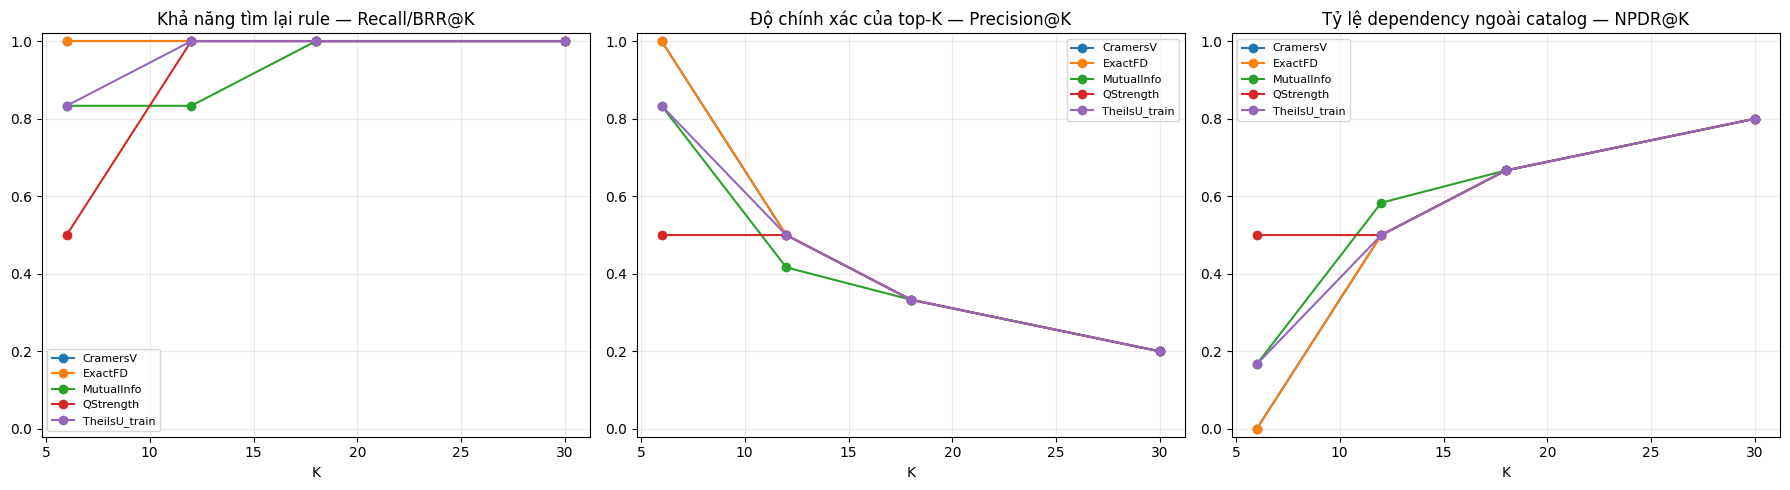

In [18]:
# 11. Biểu đồ Alignment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for method, group in alignment.groupby("method"):
    axes[0].plot(group["K"], group["Recall@K_BRR"], marker="o", label=method)
    axes[1].plot(group["K"], group["Precision@K"], marker="o", label=method)
    axes[2].plot(group["K"], group["NPDR@K"], marker="o", label=method)

axes[0].set_title("Khả năng tìm lại rule — Recall/BRR@K")
axes[1].set_title("Độ chính xác của top-K — Precision@K")
axes[2].set_title("Tỷ lệ dependency ngoài catalog — NPDR@K")

for ax in axes:
    ax.set_xlabel("K")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Taxonomy của dependency ngoài catalog

Các dependency ngoài catalog được chia thành:

- Rule đã định nghĩa.
- Reverse dependency.
- Sibling-derived dependency.
- Statistical dependency.
- Potential rule candidate.

,lhs,rhs,TheilsU_train,TheilsU_test,generalization_gap,taxonomy
52,WKHP,working_hours_group,0.693,0.693,0.000,predefined_rule
23,SCHL,education_group,0.693,0.693,0.000,predefined_rule
203,income_group,income_label,0.693,0.693,0.000,reverse_dependency
111,income_label,income_group,0.693,0.693,0.000,predefined_rule
53,WKHP,fulltime_status,0.693,0.693,0.000,predefined_rule
40,MAR,marital_group,0.693,0.693,0.000,predefined_rule
8,AGEP,age_group,0.693,0.693,0.000,predefined_rule
165,working_hours_group,fulltime_status,0.693,0.693,-0.000,sibling_derived_dependency
184,marital_group,MAR,0.438,0.443,-0.005,reverse_dependency
179,fulltime_status,working_hours_group,0.349,0.347,0.001,sibling_derived_dependency


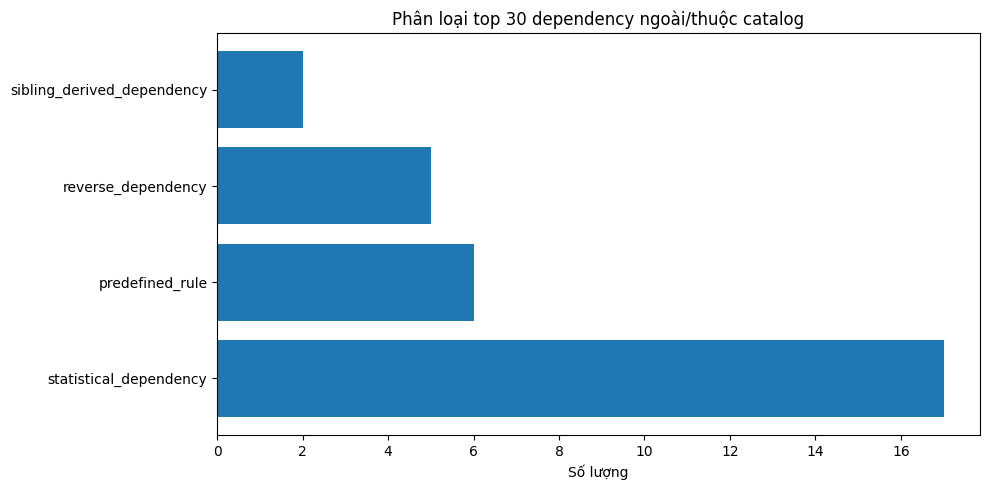

In [19]:
# 12. Taxonomy
DERIVED_SOURCE = {
    "age_group": "AGEP",
    "education_group": "SCHL",
    "working_hours_group": "WKHP",
    "fulltime_status": "WKHP",
    "marital_group": "MAR",
    "income_group": "income_label",
}

def classify_dependency(lhs: str, rhs: str, score: float) -> str:
    if (lhs, rhs) in rule_edges:
        return "predefined_rule"

    if (rhs, lhs) in rule_edges:
        return "reverse_dependency"

    if lhs in DERIVED_SOURCE and rhs in DERIVED_SOURCE:
        if DERIVED_SOURCE[lhs] == DERIVED_SOURCE[rhs]:
            return "sibling_derived_dependency"

    if score >= 0.30:
        return "potential_candidate_or_strong_statistical"

    return "statistical_dependency"

ranked_taxonomy = (
    directed_scores
      .sort_values("TheilsU_train", ascending=False)
      .head(30)
      .copy()
)

ranked_taxonomy["taxonomy"] = ranked_taxonomy.apply(
    lambda row: classify_dependency(
        row["lhs"], row["rhs"], row["TheilsU_train"]
    ),
    axis=1
)

taxonomy_counts = (
    ranked_taxonomy["taxonomy"]
      .value_counts()
      .rename_axis("taxonomy")
      .reset_index(name="count")
)

display(ranked_taxonomy[[
    "lhs", "rhs", "TheilsU_train", "TheilsU_test",
    "generalization_gap", "taxonomy"
]].round(3))

plt.figure(figsize=(10, 5))
plt.barh(taxonomy_counts["taxonomy"], taxonomy_counts["count"])
plt.title("Phân loại top 30 dependency ngoài/thuộc catalog")
plt.xlabel("Số lượng")
plt.tight_layout()
plt.show()

## 9. Xây dựng MinedRulesValidator đúng nghĩa

Quy trình:

1. Chọn dependency mạnh chỉ từ **train**.
2. Với mỗi dependency, học mapping `lhs → mode(rhs)` trên train.
3. Chỉ giữ nhóm có đủ support và purity.
4. Dùng mapping đã học để kiểm tra test.

Rule catalog mô phỏng không được dùng để xây dựng validator này.

In [20]:
# 13. Học mined rules từ train
def learn_mapping_rule(
    data: pd.DataFrame,
    lhs: str,
    rhs: str,
    min_group_support: int = 5,
    min_group_purity: float = 0.98
) -> Dict:
    temp = pd.DataFrame({
        "lhs": data[lhs],
        "rhs": data[rhs],
    }).dropna()

    mapping = {}
    group_stats = []

    for lhs_value, group in temp.groupby("lhs", observed=True):
        counts = group["rhs"].value_counts(dropna=False)
        support = len(group)
        expected = counts.index[0]
        purity = counts.iloc[0] / support

        if support >= min_group_support and purity >= min_group_purity:
            mapping[lhs_value] = expected

        group_stats.append({
            "lhs_value": lhs_value,
            "support": support,
            "expected_rhs": expected,
            "purity": purity,
        })

    return {
        "lhs": lhs,
        "rhs": rhs,
        "mapping": mapping,
        "coverage_train": len(mapping),
        "group_stats": pd.DataFrame(group_stats),
    }

candidate_edges = (
    directed_scores[
        (directed_scores["rhs_cardinality"] <= MAX_RHS_CARDINALITY) &
        (
            (directed_scores["ExactFD"] == 1.0) |
            (directed_scores["TheilsU_train"] >= MIN_THEILS_U)
        )
    ]
    .sort_values(
        ["ExactFD", "TheilsU_train", "QStrength"],
        ascending=False
    )
    .head(MINED_RULE_LIMIT)
)

mined_rules = []
for row in candidate_edges.itertuples():
    learned = learn_mapping_rule(
        train_df,
        row.lhs,
        row.rhs,
        MIN_GROUP_SUPPORT,
        MIN_GROUP_PURITY
    )

    if learned["mapping"]:
        learned["ExactFD"] = row.ExactFD
        learned["TheilsU_train"] = row.TheilsU_train
        learned["TheilsU_test"] = row.TheilsU_test
        learned["is_catalog_rule"] = (row.lhs, row.rhs) in rule_edges
        mined_rules.append(learned)

mined_rule_summary = pd.DataFrame([
    {
        "lhs": rule["lhs"],
        "rhs": rule["rhs"],
        "mapped_lhs_values": len(rule["mapping"]),
        "ExactFD": rule["ExactFD"],
        "TheilsU_train": rule["TheilsU_train"],
        "TheilsU_test": rule["TheilsU_test"],
        "is_catalog_rule": rule["is_catalog_rule"],
    }
    for rule in mined_rules
])

print("Các rule thực sự được học từ train:")
display(mined_rule_summary.round(3))

def mined_rule_validator(data: pd.DataFrame, rules: List[Dict]) -> np.ndarray:
    row_error = np.zeros(len(data), dtype=bool)

    for rule in rules:
        lhs = rule["lhs"]
        rhs = rule["rhs"]
        mapping = rule["mapping"]

        expected = data[lhs].map(mapping)
        known = expected.notna() & data[lhs].notna() & data[rhs].notna()
        mismatch = known & (data[rhs] != expected)

        row_error |= mismatch.to_numpy()

    return row_error

clean_mined_pred = mined_rule_validator(test_df, mined_rules)
clean_expert_pred = expert_rule_validator(test_df)

clean_validator_result = pd.DataFrame([
    {
        "validator": "ExpertRules",
        "clean_false_positive_rows": int(clean_expert_pred.sum()),
        "clean_false_positive_rate": clean_expert_pred.mean(),
    },
    {
        "validator": "MinedRules",
        "clean_false_positive_rows": int(clean_mined_pred.sum()),
        "clean_false_positive_rate": clean_mined_pred.mean(),
    },
])

display(clean_validator_result.round(6))

Các rule thực sự được học từ train:


,lhs,rhs,mapped_lhs_values,ExactFD,TheilsU_train,TheilsU_test,is_catalog_rule
0,WKHP,working_hours_group,87,1.0,0.693,0.693,True
1,SCHL,education_group,24,1.0,0.693,0.693,True
2,income_label,income_group,2,1.0,0.693,0.693,True
3,income_group,income_label,2,1.0,0.693,0.693,False
4,WKHP,fulltime_status,87,1.0,0.693,0.693,True
5,MAR,marital_group,5,1.0,0.693,0.693,True
6,AGEP,age_group,76,1.0,0.693,0.693,True
7,working_hours_group,fulltime_status,4,1.0,0.693,0.693,False


,validator,clean_false_positive_rows,clean_false_positive_rate
0,ExpertRules,0,0.0
1,MinedRules,0,0.0


## 10. Stress test với tỷ lệ lỗi chính xác

Bốn scenario được đánh giá bằng Precision, Recall và F1:

1. `derived_rule_error`
2. `base_stale_error`
3. `invalid_code_error`
4. `missingness_error`

`background_covariate_shift` không được xem là lỗi cấp dòng, nên chỉ dùng để đánh giá DDS.

In [21]:
# 14. Helper để chèn lỗi
DERIVED_DOMAINS = {
    "age_group": ["Under18", "WorkingAge", "Senior"],
    "education_group": ["BelowHS", "HS_College", "BachelorPlus"],
    "working_hours_group": ["VeryLow", "PartTime", "Standard", "Overtime"],
    "fulltime_status": ["Fulltime", "NonFulltime"],
    "marital_group": ["Married", "NotMarried"],
    "income_group": ["HighIncome", "LowIncome"],
}

DERIVED_RULE_PAIRS = [
    ("AGEP", "age_group"),
    ("SCHL", "education_group"),
    ("WKHP", "working_hours_group"),
    ("WKHP", "fulltime_status"),
    ("MAR", "marital_group"),
    ("income_label", "income_group"),
]

def wrong_value(current, domain, rng):
    candidates = [value for value in domain if value != current]
    return rng.choice(candidates) if candidates else current

def force_base_to_other_group(row: pd.Series, base_col: str, rng) -> float:
    if base_col == "AGEP":
        current_group = row["age_group"]
        choices = {
            "Under18": [25, 70],
            "WorkingAge": [17, 70],
            "Senior": [17, 30],
        }
        return int(rng.choice(choices.get(current_group, [17, 30, 70])))

    if base_col == "SCHL":
        current_group = row["education_group"]
        choices = {
            "BelowHS": [18, 22],
            "HS_College": [10, 22],
            "BachelorPlus": [10, 18],
        }
        return int(rng.choice(choices.get(current_group, [10, 18, 22])))

    if base_col == "WKHP":
        current_group = row["working_hours_group"]
        choices = {
            "VeryLow": [20, 40, 55],
            "PartTime": [10, 40, 55],
            "Standard": [10, 20, 55],
            "Overtime": [10, 20, 40],
        }
        return int(rng.choice(choices.get(current_group, [10, 20, 40, 55])))

    if base_col == "MAR":
        return 2 if row["marital_group"] == "Married" else 1

    if base_col == "income_label":
        return 1 - int(row["income_label"])

    return row[base_col]

def inject_row_level_errors(
    clean_data: pd.DataFrame,
    scenario: str,
    rate: float,
    seed: int
) -> Tuple[pd.DataFrame, np.ndarray]:
    rng = np.random.default_rng(seed)
    noisy = clean_data.copy(deep=True)

    n_rows = len(noisy)
    n_inject = max(1, int(round(n_rows * rate)))
    selected = rng.choice(n_rows, size=n_inject, replace=False)

    injected = np.zeros(n_rows, dtype=bool)
    injected[selected] = True

    if scenario == "derived_rule_error":
        for idx in selected:
            _, rhs = DERIVED_RULE_PAIRS[rng.integers(len(DERIVED_RULE_PAIRS))]
            noisy.at[idx, rhs] = wrong_value(
                noisy.at[idx, rhs],
                DERIVED_DOMAINS[rhs],
                rng
            )

    elif scenario == "base_stale_error":
        base_choices = ["AGEP", "SCHL", "WKHP", "MAR", "income_label"]
        for idx in selected:
            base_col = rng.choice(base_choices)
            noisy.at[idx, base_col] = force_base_to_other_group(
                noisy.loc[idx], base_col, rng
            )
            # Giữ nguyên biến dẫn xuất cũ để tạo stale inconsistency

    elif scenario == "invalid_code_error":
        invalid_values = {
            "AGEP": 999,
            "SCHL": 99,
            "MAR": 99,
            "WKHP": 999,
            "SEX": 9,
            "income_label": 3,
        }
        columns = list(invalid_values.keys())

        for idx in selected:
            col = rng.choice(columns)
            noisy.at[idx, col] = invalid_values[col]

    elif scenario == "missingness_error":
        columns = [
            "AGEP", "SCHL", "MAR", "WKHP", "SEX", "income_label",
            "age_group", "education_group", "working_hours_group",
            "fulltime_status", "marital_group", "income_group"
        ]

        for idx in selected:
            col = rng.choice(columns)
            noisy.at[idx, col] = np.nan

    else:
        raise ValueError(f"Scenario không hợp lệ: {scenario}")

    return noisy, injected

def inject_background_shift(
    clean_data: pd.DataFrame,
    rate: float,
    seed: int
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    shifted = clean_data.copy(deep=True)

    n_rows = len(shifted)
    n_change = max(1, int(round(n_rows * rate)))
    selected = rng.choice(n_rows, size=n_change, replace=False)

    for idx in selected:
        col = rng.choice(["RELP", "COW", "state"])
        domain = shifted[col].dropna().unique().tolist()
        current = shifted.at[idx, col]
        shifted.at[idx, col] = wrong_value(current, domain, rng)

    return shifted

In [22]:
# 15. Chạy stress test nhiều seed
SCENARIOS = [
    "derived_rule_error",
    "base_stale_error",
    "invalid_code_error",
    "missingness_error",
]

def evaluate_binary(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[False, True]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": fpr,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }

stress_rows = []

for scenario in tqdm(SCENARIOS, desc="Stress test"):
    for rate in NOISE_RATES:
        for seed in STRESS_SEEDS:
            noisy, injected = inject_row_level_errors(
                test_df,
                scenario,
                rate,
                seed
            )

            predictions = {
                "ExpertRules": expert_rule_validator(noisy),
                "MinedRules": mined_rule_validator(noisy, mined_rules),
            }

            for validator_name, prediction in predictions.items():
                metrics = evaluate_binary(injected, prediction)

                stress_rows.append({
                    "scenario": scenario,
                    "noise_rate": rate,
                    "seed": seed,
                    "validator": validator_name,
                    "actual_injected_rows": int(injected.sum()),
                    **metrics
                })

stress_detail = pd.DataFrame(stress_rows)

stress_summary = (
    stress_detail
      .groupby(["scenario", "noise_rate", "validator"], as_index=False)
      .agg(
          precision_mean=("precision", "mean"),
          precision_std=("precision", "std"),
          recall_mean=("recall", "mean"),
          recall_std=("recall", "std"),
          f1_mean=("f1", "mean"),
          f1_std=("f1", "std"),
          fpr_mean=("false_positive_rate", "mean"),
          injected_rows=("actual_injected_rows", "mean"),
      )
)

display(stress_summary.round(3))

Stress test:   0%|          | 0/4 [00:00<?, ?it/s]

,scenario,noise_rate,validator,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fpr_mean,injected_rows
0,base_stale_error,0.01,ExpertRules,1.0,0.0,1.000,0.000,1.000,0.000,0.0,200.0
1,base_stale_error,0.01,MinedRules,1.0,0.0,1.000,0.000,1.000,0.000,0.0,200.0
2,base_stale_error,0.05,ExpertRules,1.0,0.0,1.000,0.000,1.000,0.000,0.0,1000.0
3,base_stale_error,0.05,MinedRules,1.0,0.0,1.000,0.000,1.000,0.000,0.0,1000.0
4,base_stale_error,0.10,ExpertRules,1.0,0.0,1.000,0.000,1.000,0.000,0.0,2000.0
5,base_stale_error,0.10,MinedRules,1.0,0.0,1.000,0.000,1.000,0.000,0.0,2000.0
6,derived_rule_error,0.01,ExpertRules,1.0,0.0,1.000,0.000,1.000,0.000,0.0,200.0
7,derived_rule_error,0.01,MinedRules,1.0,0.0,1.000,0.000,1.000,0.000,0.0,200.0
8,derived_rule_error,0.05,ExpertRules,1.0,0.0,1.000,0.000,1.000,0.000,0.0,1000.0
9,derived_rule_error,0.05,MinedRules,1.0,0.0,1.000,0.000,1.000,0.000,0.0,1000.0


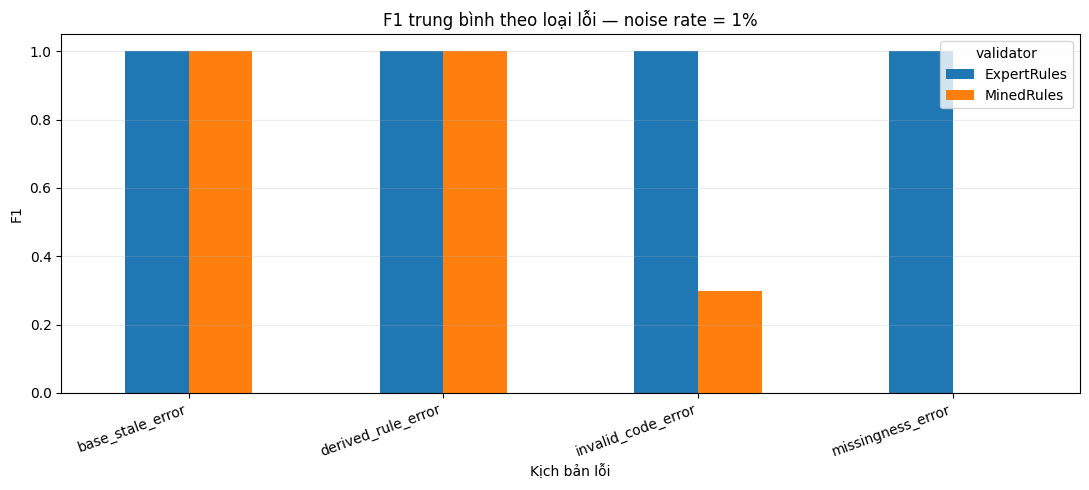

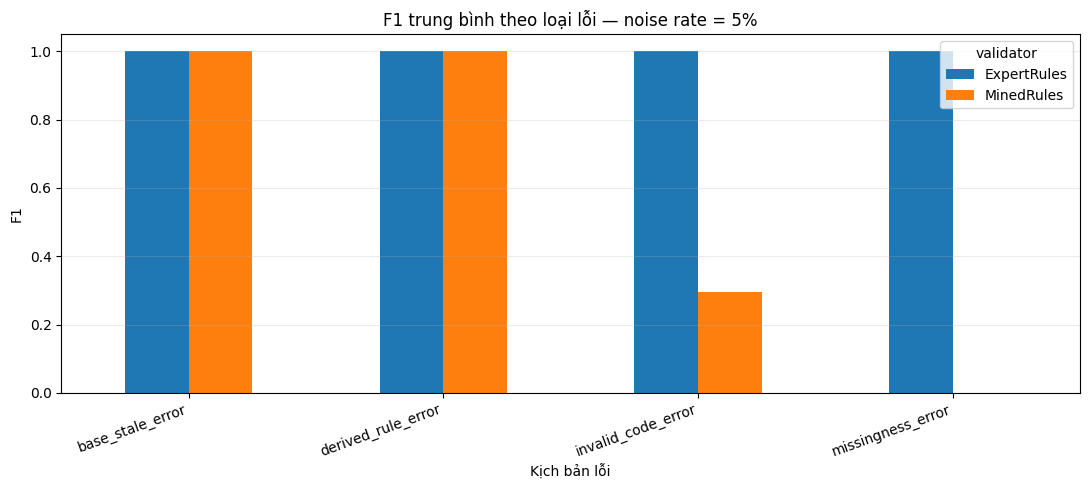

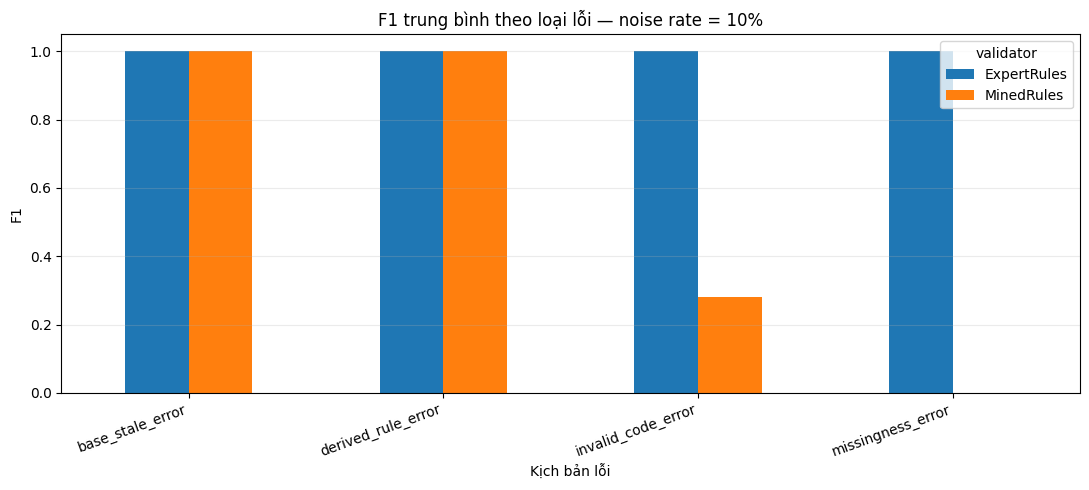

In [23]:
# 16. Chart F1 theo scenario và noise rate
for rate in NOISE_RATES:
    plot_data = stress_summary[stress_summary["noise_rate"] == rate].copy()
    pivot = plot_data.pivot(
        index="scenario",
        columns="validator",
        values="f1_mean"
    )

    pivot.plot(kind="bar", figsize=(11, 5))
    plt.title(f"F1 trung bình theo loại lỗi — noise rate = {rate:.0%}")
    plt.ylabel("F1")
    plt.xlabel("Kịch bản lỗi")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 11. Dependency Drift Score với bootstrap sạch

- DDS so sánh ma trận Theil's U của dữ liệu clean và dữ liệu thay đổi.
- Bootstrap sạch tạo ngưỡng tham chiếu 95%.
- DDS không chỉ ra dòng nào sai; nó chỉ cảnh báo cấu trúc dependency đã thay đổi.

In [24]:
# 17. DDS helpers
def sample_for_dds(data: pd.DataFrame, seed: int) -> pd.DataFrame:
    n = min(DDS_SAMPLE_SIZE, len(data))
    return data.sample(n=n, random_state=seed).reset_index(drop=True)

DDS_COLS = [
    "AGEP", "SCHL", "MAR", "WKHP", "SEX", "RELP", "COW",
    "income_label", "state",
    "age_group", "education_group", "working_hours_group",
    "fulltime_status", "marital_group", "income_group"
]
DDS_COLS = [c for c in DDS_COLS if c in test_df.columns]

def theils_u_matrix(data: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for lhs in cols:
        for rhs in cols:
            matrix.loc[lhs, rhs] = 1.0 if lhs == rhs else theils_u(data, lhs, rhs)

    return matrix

def dependency_drift_score(
    matrix_a: pd.DataFrame,
    matrix_b: pd.DataFrame
) -> float:
    return float(np.abs(matrix_a.to_numpy() - matrix_b.to_numpy()).mean())

baseline_sample = sample_for_dds(test_df, RANDOM_SEED)
baseline_matrix = theils_u_matrix(baseline_sample, DDS_COLS)

# Bootstrap null: clean vs clean
bootstrap_dds = []

for rep in tqdm(range(DDS_BOOTSTRAP_REPS), desc="Bootstrap DDS sạch"):
    sample_a = sample_for_dds(test_df, 1000 + rep)
    sample_b = sample_for_dds(test_df, 2000 + rep)

    matrix_a = theils_u_matrix(sample_a, DDS_COLS)
    matrix_b = theils_u_matrix(sample_b, DDS_COLS)

    bootstrap_dds.append(dependency_drift_score(matrix_a, matrix_b))

dds_clean_threshold_95 = float(np.quantile(bootstrap_dds, 0.95))

print("DDS bootstrap sạch:")
display(pd.Series(bootstrap_dds, name="DDS_clean_bootstrap").describe().to_frame())
print(f"Ngưỡng DDS sạch 95%: {dds_clean_threshold_95:.6f}")

Bootstrap DDS sạch:   0%|          | 0/10 [00:00<?, ?it/s]

DDS bootstrap sạch:


,DDS_clean_bootstrap
count,10.000000
mean,0.001995
std,0.000323
min,0.001506
25%,0.001822
50%,0.001982
75%,0.002197
max,0.002537


Ngưỡng DDS sạch 95%: 0.002448


In [25]:
# 18. DDS theo scenario
dds_rows = []

for scenario in tqdm(SCENARIOS, desc="DDS theo lỗi"):
    for rate in NOISE_RATES:
        for seed in DDS_SEEDS:
            noisy, _ = inject_row_level_errors(test_df, scenario, rate, seed)
            noisy_sample = sample_for_dds(noisy, seed)
            noisy_matrix = theils_u_matrix(noisy_sample, DDS_COLS)
            score = dependency_drift_score(baseline_matrix, noisy_matrix)

            dds_rows.append({
                "scenario": scenario,
                "noise_rate": rate,
                "seed": seed,
                "DDS": score,
                "above_clean_95_threshold": score > dds_clean_threshold_95,
            })

# Background shift chỉ dùng cho DDS
for rate in NOISE_RATES:
    for seed in DDS_SEEDS:
        shifted = inject_background_shift(test_df, rate, seed)
        shifted_sample = sample_for_dds(shifted, seed)
        shifted_matrix = theils_u_matrix(shifted_sample, DDS_COLS)
        score = dependency_drift_score(baseline_matrix, shifted_matrix)

        dds_rows.append({
            "scenario": "background_covariate_shift",
            "noise_rate": rate,
            "seed": seed,
            "DDS": score,
            "above_clean_95_threshold": score > dds_clean_threshold_95,
        })

dds_detail = pd.DataFrame(dds_rows)

dds_summary = (
    dds_detail
      .groupby(["scenario", "noise_rate"], as_index=False)
      .agg(
          DDS_mean=("DDS", "mean"),
          DDS_std=("DDS", "std"),
          proportion_above_threshold=("above_clean_95_threshold", "mean"),
      )
)

display(dds_summary.round(6))

DDS theo lỗi:   0%|          | 0/4 [00:00<?, ?it/s]

,scenario,noise_rate,DDS_mean,DDS_std,proportion_above_threshold
0,background_covariate_shift,0.01,0.001414,0.001106,0.000000
1,background_covariate_shift,0.05,0.001595,0.001001,0.000000
2,background_covariate_shift,0.10,0.001972,0.000951,0.333333
3,base_stale_error,0.01,0.001795,0.001006,0.000000
4,base_stale_error,0.05,0.002834,0.000693,0.666667
5,base_stale_error,0.10,0.004280,0.000543,1.000000
6,derived_rule_error,0.01,0.002051,0.000838,0.666667
7,derived_rule_error,0.05,0.004334,0.000539,1.000000
8,derived_rule_error,0.10,0.006774,0.000528,1.000000
9,invalid_code_error,0.01,0.001526,0.001006,0.000000


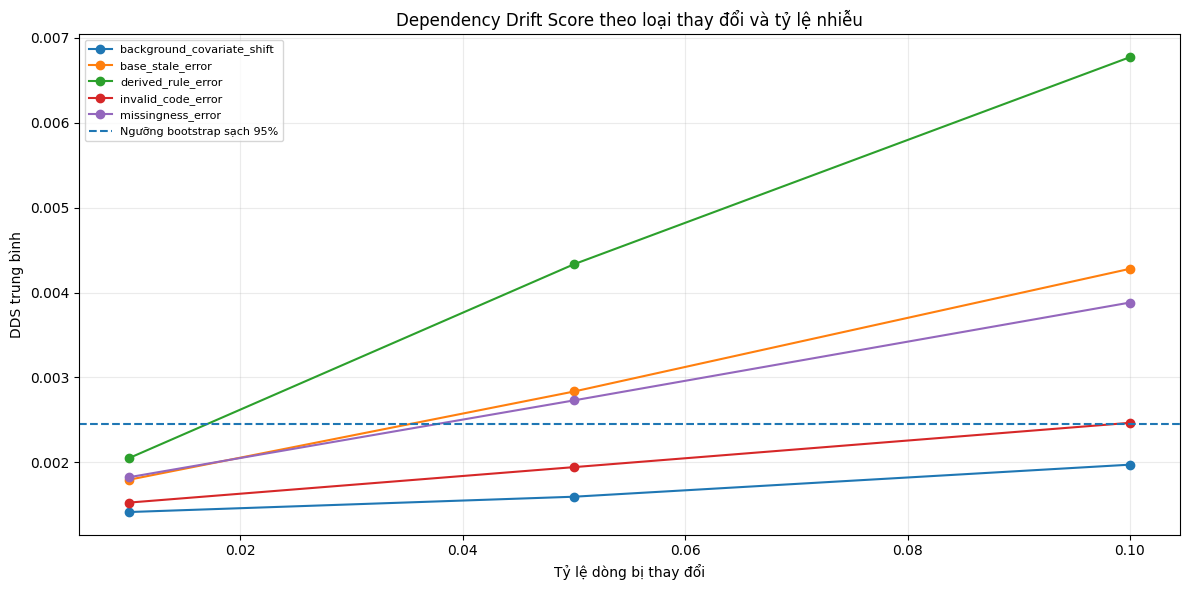

In [26]:
# 19. Chart DDS
plt.figure(figsize=(12, 6))

for scenario, group in dds_summary.groupby("scenario"):
    plt.plot(
        group["noise_rate"],
        group["DDS_mean"],
        marker="o",
        label=scenario
    )

plt.axhline(
    dds_clean_threshold_95,
    linestyle="--",
    label="Ngưỡng bootstrap sạch 95%"
)

plt.title("Dependency Drift Score theo loại thay đổi và tỷ lệ nhiễu")
plt.xlabel("Tỷ lệ dòng bị thay đổi")
plt.ylabel("DDS trung bình")
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 12. State-level drift theo leave-one-state-out

Mỗi bang được so với baseline tạo từ **4 bang còn lại**, tránh việc baseline chứa chính bang đang đánh giá.

State LOO DDS:   0%|          | 0/5 [00:00<?, ?it/s]

,state,state_rows,balanced_rows_used,DDS_vs_other_states,above_clean_95_threshold
2,IL,2232,2232,0.067245,True
1,FL,3295,3295,0.066305,True
0,CA,6515,5000,0.066090,True
4,TX,4527,4527,0.065339,True
3,NY,3431,3431,0.065093,True


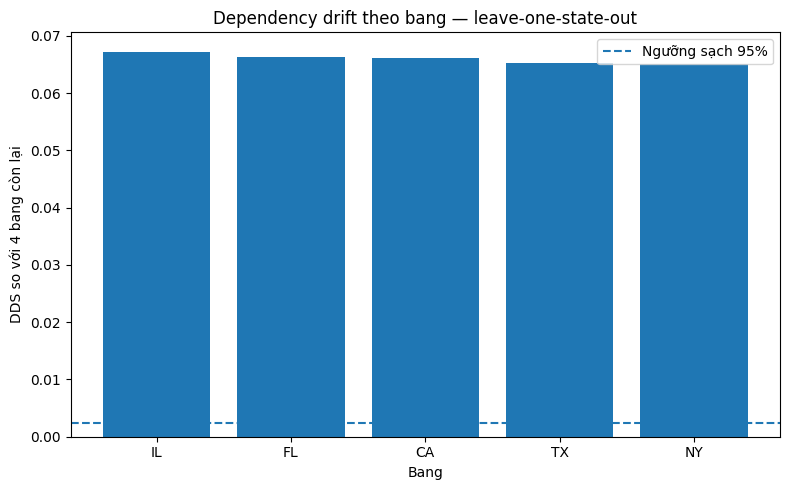

In [27]:
# 20. State-level leave-one-out DDS
state_rows = []

for state in tqdm(sorted(test_df["state"].dropna().unique()), desc="State LOO DDS"):
    state_data = test_df[test_df["state"] == state]
    other_data = test_df[test_df["state"] != state]

    n = min(DDS_SAMPLE_SIZE, len(state_data), len(other_data))

    state_sample = state_data.sample(n=n, random_state=RANDOM_SEED)
    other_sample = other_data.sample(n=n, random_state=RANDOM_SEED)

    state_matrix = theils_u_matrix(state_sample, DDS_COLS)
    other_matrix = theils_u_matrix(other_sample, DDS_COLS)

    score = dependency_drift_score(state_matrix, other_matrix)

    state_rows.append({
        "state": state,
        "state_rows": len(state_data),
        "balanced_rows_used": n,
        "DDS_vs_other_states": score,
        "above_clean_95_threshold": score > dds_clean_threshold_95,
    })

state_drift = pd.DataFrame(state_rows).sort_values(
    "DDS_vs_other_states",
    ascending=False
)

display(state_drift.round(6))

plt.figure(figsize=(8, 5))
plt.bar(state_drift["state"], state_drift["DDS_vs_other_states"])
plt.axhline(dds_clean_threshold_95, linestyle="--", label="Ngưỡng sạch 95%")
plt.title("Dependency drift theo bang — leave-one-state-out")
plt.xlabel("Bang")
plt.ylabel("DDS so với 4 bang còn lại")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Biểu đồ độ khái quát của dependency

Biểu đồ dưới đây cho thấy dependency nào mạnh trên train nhưng suy giảm trên test.

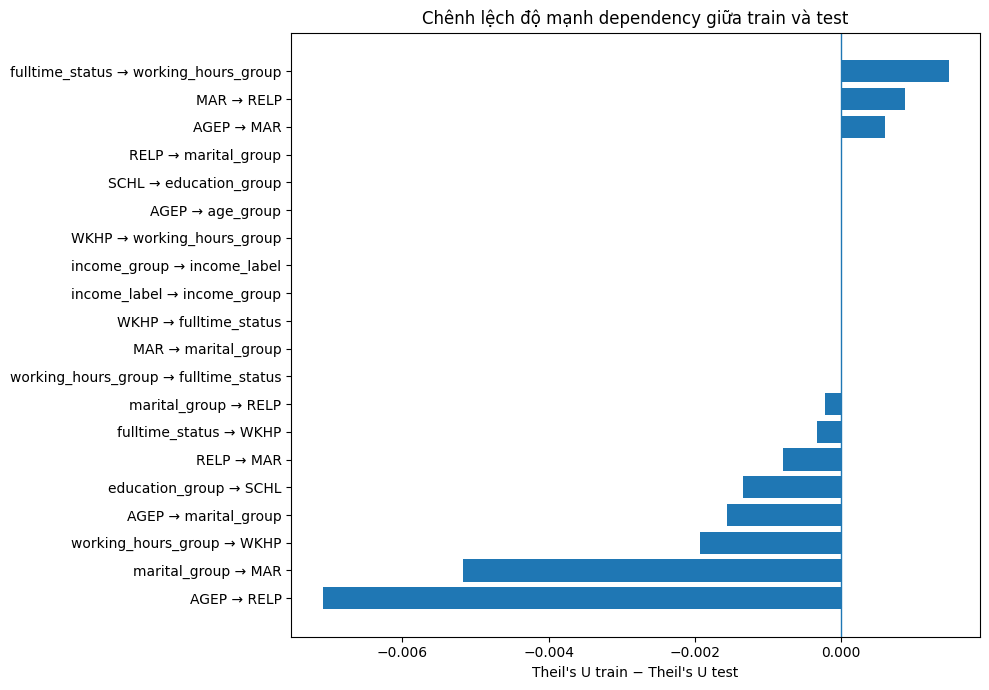

,lhs,rhs,TheilsU_train,TheilsU_test,generalization_gap
4,AGEP,RELP,0.0942,0.1013,-0.0071
184,marital_group,MAR,0.4383,0.4435,-0.0052
157,working_hours_group,WKHP,0.3020,0.3039,-0.0019
12,AGEP,marital_group,0.1074,0.1090,-0.0016
141,education_group,SCHL,0.2829,0.2842,-0.0013
72,RELP,MAR,0.2100,0.2108,-0.0008
171,fulltime_status,WKHP,0.1519,0.1522,-0.0003
187,marital_group,RELP,0.1224,0.1226,-0.0002
165,working_hours_group,fulltime_status,0.6931,0.6931,-0.0000
40,MAR,marital_group,0.6931,0.6931,0.0000


In [28]:
# 21. Generalization gap chart
gap_plot = (
    directed_scores
      .sort_values("TheilsU_train", ascending=False)
      .head(20)
      .copy()
)

gap_plot["edge"] = gap_plot["lhs"] + " → " + gap_plot["rhs"]
gap_plot = gap_plot.sort_values("generalization_gap", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(gap_plot["edge"], gap_plot["generalization_gap"])
plt.axvline(0, linewidth=1)
plt.title("Chênh lệch độ mạnh dependency giữa train và test")
plt.xlabel("Theil's U train − Theil's U test")
plt.tight_layout()
plt.show()

display(
    gap_plot[[
        "lhs", "rhs", "TheilsU_train", "TheilsU_test",
        "generalization_gap"
    ]].round(4)
)

## 14. Tóm tắt số liệu tự động cho phần Kết quả

Cell cuối tạo đoạn diễn giải tiếng Việt dựa trên chính kết quả vừa chạy.

In [29]:
# 22. Auto-generated result summary
best_alignment = alignment.sort_values(
    ["K", "Recall@K_BRR", "Precision@K"],
    ascending=[True, False, False]
)

k6 = alignment[alignment["K"] == 6].sort_values(
    ["Recall@K_BRR", "Precision@K"],
    ascending=False
)

k30 = alignment[alignment["K"] == 30].sort_values(
    ["Recall@K_BRR", "Precision@K"],
    ascending=False
)

stress_10 = stress_summary[stress_summary["noise_rate"] == 0.10]
dds_max = dds_summary.sort_values("DDS_mean", ascending=False).iloc[0]
state_max = state_drift.iloc[0]

summary_lines = [
    f"Dữ liệu thô gồm {len(raw_df):,} dòng và {raw_df.shape[1]} cột. "
    f"Tập phân tích gồm {len(df):,} dòng; train có {len(train_df):,} dòng và test có {len(test_df):,} dòng.",

    f"Trên dữ liệu test sạch, tổng số vi phạm của 16 phép kiểm tra dependency-like là "
    f"{int(clean_summary['violations'].sum())}.",

    f"Ở K=6, phương pháp tốt nhất đạt Recall/BRR={k6.iloc[0]['Recall@K_BRR']:.3f}, "
    f"Precision={k6.iloc[0]['Precision@K']:.3f} và NPDR={k6.iloc[0]['NPDR@K']:.3f}.",

    f"Ở K=30, phương pháp tốt nhất vẫn đạt Recall/BRR={k30.iloc[0]['Recall@K_BRR']:.3f}, "
    f"nhưng Precision giảm còn {k30.iloc[0]['Precision@K']:.3f} và NPDR tăng lên "
    f"{k30.iloc[0]['NPDR@K']:.3f}.",

    f"MinedRulesValidator được xây dựng từ {len(mined_rules)} dependency học trên train. "
    f"Tỷ lệ báo sai trên test sạch là {clean_mined_pred.mean():.6f}.",

    f"DDS trung bình cao nhất thuộc kịch bản '{dds_max['scenario']}' tại mức nhiễu "
    f"{dds_max['noise_rate']:.0%}, với DDS={dds_max['DDS_mean']:.6f}. "
    f"Ngưỡng bootstrap sạch 95% là {dds_clean_threshold_95:.6f}.",

    f"Bang có DDS leave-one-state-out cao nhất là {state_max['state']} "
    f"với DDS={state_max['DDS_vs_other_states']:.6f}.",
]

print("\nTÓM TẮT KẾT QUẢ V3.1\n")
for index, line in enumerate(summary_lines, start=1):
    print(f"{index}. {line}")

print("\nBảng F1 ở noise rate = 10%:")
display(
    stress_10[[
        "scenario", "validator",
        "precision_mean", "recall_mean", "f1_mean", "f1_std", "fpr_mean"
    ]].round(3)
)


TÓM TẮT KẾT QUẢ V3.1

1. Dữ liệu thô gồm 600,551 dòng và 12 cột. Tập phân tích gồm 100,000 dòng; train có 80,000 dòng và test có 20,000 dòng.
2. Trên dữ liệu test sạch, tổng số vi phạm của 16 phép kiểm tra dependency-like là 0.
3. Ở K=6, phương pháp tốt nhất đạt Recall/BRR=1.000, Precision=1.000 và NPDR=0.000.
4. Ở K=30, phương pháp tốt nhất vẫn đạt Recall/BRR=1.000, nhưng Precision giảm còn 0.200 và NPDR tăng lên 0.800.
5. MinedRulesValidator được xây dựng từ 8 dependency học trên train. Tỷ lệ báo sai trên test sạch là 0.000000.
6. DDS trung bình cao nhất thuộc kịch bản 'derived_rule_error' tại mức nhiễu 10%, với DDS=0.006774. Ngưỡng bootstrap sạch 95% là 0.002448.
7. Bang có DDS leave-one-state-out cao nhất là IL với DDS=0.067245.

Bảng F1 ở noise rate = 10%:


,scenario,validator,precision_mean,recall_mean,f1_mean,f1_std,fpr_mean
4,base_stale_error,ExpertRules,1.0,1.000,1.000,0.000,0.0
5,base_stale_error,MinedRules,1.0,1.000,1.000,0.000,0.0
10,derived_rule_error,ExpertRules,1.0,1.000,1.000,0.000,0.0
11,derived_rule_error,MinedRules,1.0,1.000,1.000,0.000,0.0
16,invalid_code_error,ExpertRules,1.0,1.000,1.000,0.000,0.0
17,invalid_code_error,MinedRules,1.0,0.164,0.281,0.013,0.0
22,missingness_error,ExpertRules,1.0,1.000,1.000,0.000,0.0
23,missingness_error,MinedRules,0.0,0.000,0.000,0.000,0.0
